### **TRABAJO PRÁCTICO N° 2: Redes Convolucionales, Detección de Objetos y Redes Recurrentes - Problema 2**
---
 1er cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
| Martinez Dufour, Caterina | M-7169/2   |
| Grimaldi, Damián Daniel   | G-5977/3   |
| Tapia, Fabrizio           | T-3095/3   |

**Docentes:** *Salvañá, Leandro* - *Fernández, Florencia*

### 1. Descripción del dataset
---

In [ ]:
!pip install torch
!pip install torchvision
!pip install ultralytics
librosa
numpy
opencv-python
matplotlib
scikit-learn
notebook
gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.0 MB/s eta 0:00:0000:01


In [6]:
# Librerías
import pandas as pd
import seaborn as sns
import yaml
#import optuna
import gdown
import zipfile
import os
import random, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix

In [7]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Carga del dataset
---

In [8]:
# ID de tu archivo de Drive
file_id = '1xiiGu2mN5KbKWM1_oRznQEL97hrkSGW_'
url = f'https://drive.google.com/uc?id={file_id}'
archivo_descargado = 'Traffic_Signs_Detection.zip' 

# Descargar el archivo
gdown.download(url, archivo_descargado, quiet=False)
# Descomprimir el archivo en la carpeta
carpeta_destino = 'dataset_problema2'

# Creamos la carpeta si no existe
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)

# Extraemos el contenido
try:
    with zipfile.ZipFile(archivo_descargado, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino)
    # Eliminar el archivo .zip descargado
    os.remove(archivo_descargado) 
    
except zipfile.BadZipFile:
    print("Error.")

Downloading...
From (original): https://drive.google.com/uc?id=1xiiGu2mN5KbKWM1_oRznQEL97hrkSGW_
From (redirected): https://drive.google.com/uc?id=1xiiGu2mN5KbKWM1_oRznQEL97hrkSGW_&confirm=t&uuid=966519c8-83ac-4a4c-a8ec-eed8e48e48d0
To: /content/Traffic_Signs_Detection.zip
100%|██████████| 105M/105M [00:01<00:00, 59.7MB/s] 


In [10]:
DATASET_2 = "dataset_problema2/car"
train = os.path.join(DATASET_2, 'train/images')
test = os.path.join(DATASET_2, 'test/images')
validation = os.path.join(DATASET_2, 'valid/images')

total = len(os.listdir(train)) + len(os.listdir(test)) + len(os.listdir(validation))

print(f"Train: {len(os.listdir(train))} ({len(os.listdir(train))/total*100:.2f}%)")
print(f"Test: {len(os.listdir(test))} ({len(os.listdir(test))/total*100:.2f}%)")
print(f"Validation: {len(os.listdir(validation))} ({len(os.listdir(validation))/total*100:.2f}%)")
print(f"Total: {total}")

#Tipos de señales de tráfico indicadas en el json
print("-------------")
with open(os.path.join(DATASET_2, 'data.yaml'), 'r') as f:
    data = yaml.safe_load(f)
    print("Clases:")
    print(data['names'])  



Train: 3530 (71.04%)
Test: 638 (12.84%)
Validation: 801 (16.12%)
Total: 4969
-------------
Clases:
['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']


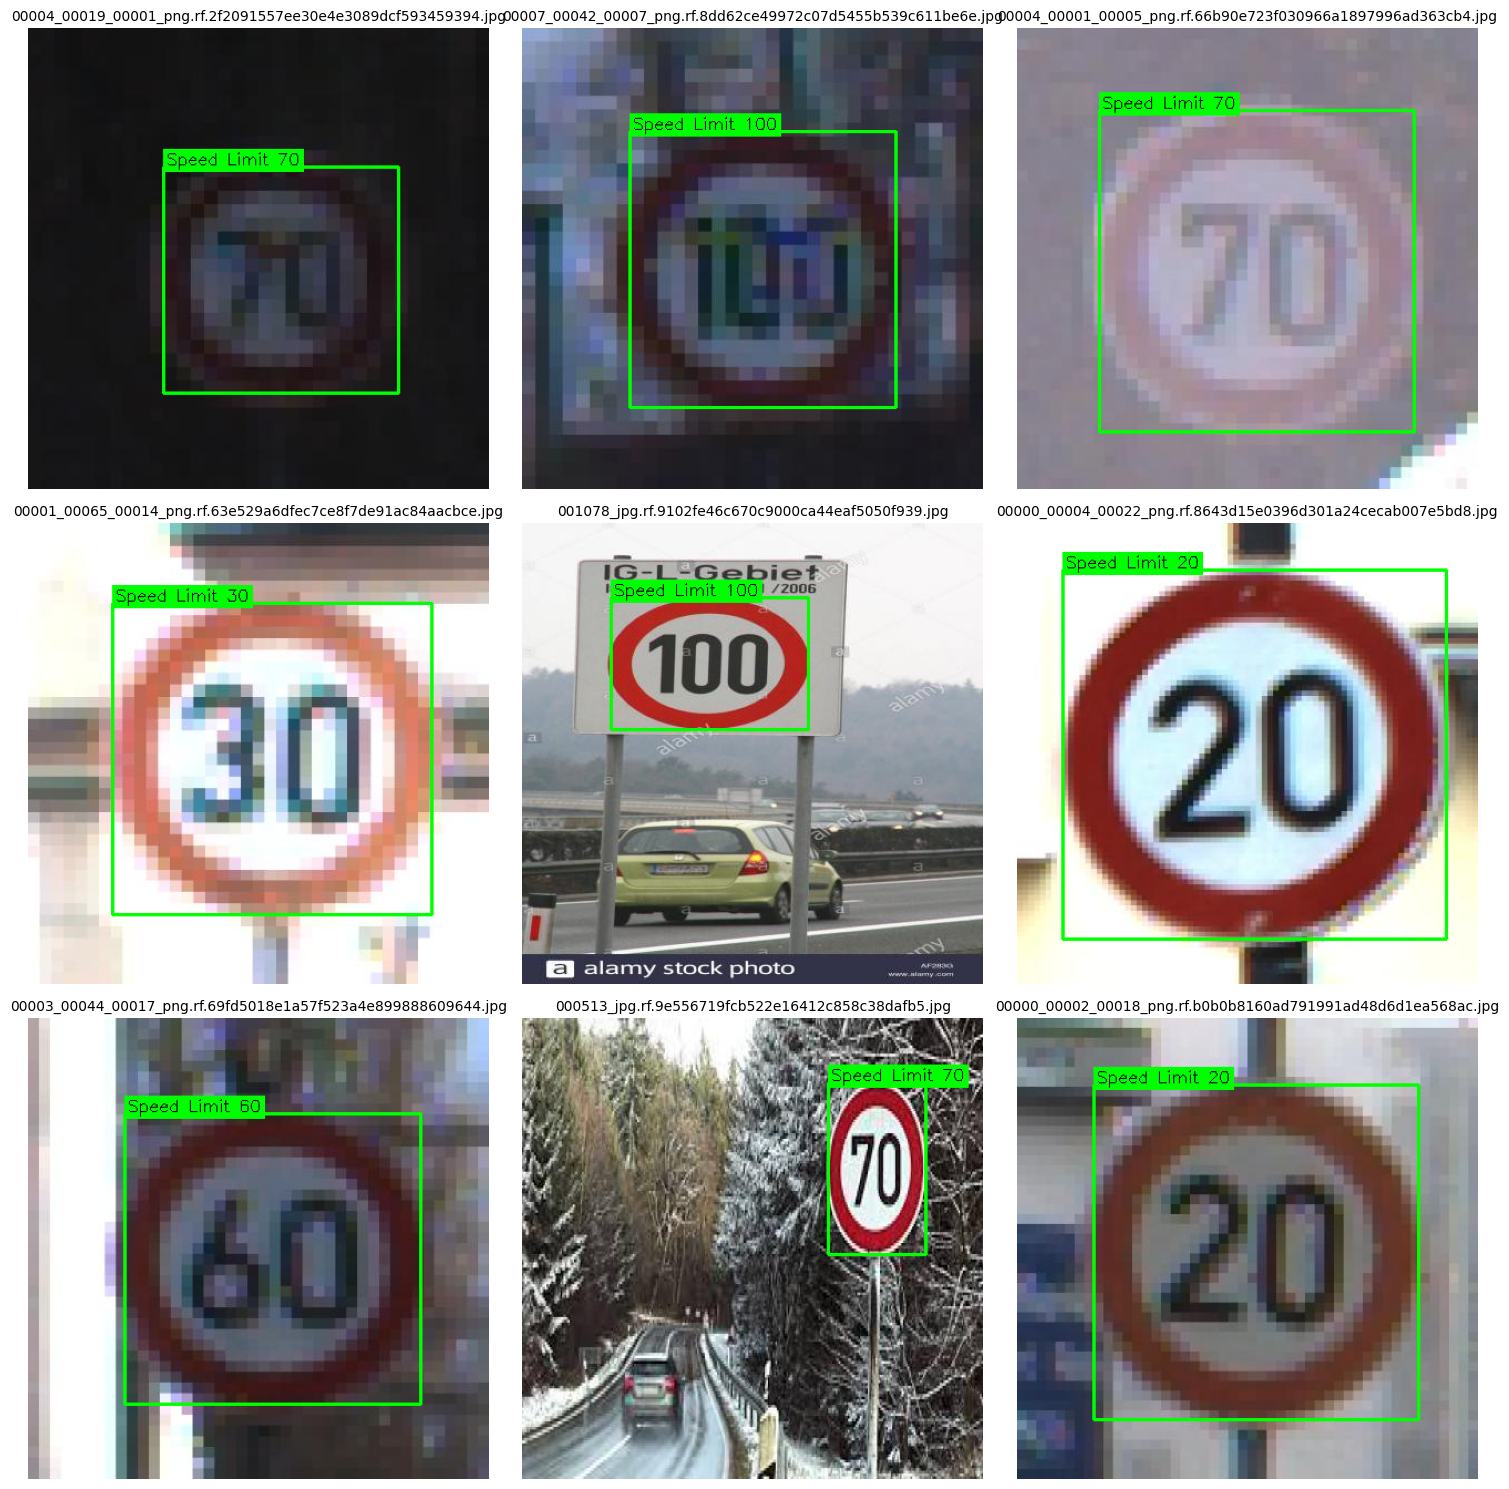

In [11]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Definimos la lista oficial de clases según el enunciado (15 clases)
names = [
    'Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100',
    'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30',
    'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70',
    'Speed Limit 80', 'Speed Limit 90', 'Stop'
]

def visualizar_anotacion(img_path, lbl_path, class_names):
    # 1. Cargar la imagen
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Error: No se pudo cargar la imagen en {img_path}")
        return None
    
    h, w = img.shape[:2]
    
    colors = [
        (0, 255, 0), (0, 0, 255), (255, 0, 0), 
        (0, 255, 255), (255, 0, 255), (255, 255, 0)
    ]
    
    if not Path(lbl_path).exists():
        print(f"Advertencia: No existe archivo de etiquetas en {lbl_path}")
        return img
        
    with open(lbl_path) as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) < 5:
                continue
                
            cls, cx, cy, bw, bh = parts
            cls = int(cls)
            
            cx, cy, bw, bh = float(cx) * w, float(cy) * h, float(bw) * w, float(bh) * h
            
            x1 = int(cx - bw / 2)
            y1 = int(cy - bh / 2)
            x2 = int(cx + bw / 2)
            y2 = int(cy + bh / 2)
            
            color = colors[i % len(colors)]
            
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            
            label = class_names[cls]
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            ty1 = max(y1, th + 4)
            
            cv2.rectangle(img, (x1, ty1 - th - 4), (x1 + tw + 4, ty1 + 4), color, -1) # -1 rellena
            cv2.putText(img, label, (x1 + 2, ty1 - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
            
    return img

# USO 
PATH_IMAGENES = Path("dataset_problema2/car/train/images")
PATH_LABELS = Path("dataset_problema2/car/train/labels")
todas_las_imagenes = list(PATH_IMAGENES.glob("*.jpg"))

CANTIDAD_A_MOSTRAR = 9
imagenes_muestra = todas_las_imagenes[:CANTIDAD_A_MOSTRAR]

if imagenes_muestra:
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.ravel() 
    
    for idx, img_path in enumerate(imagenes_muestra):
        lbl_path = PATH_LABELS / f"{img_path.stem}.txt"
        
        resultado_img = visualizar_anotacion(img_path, lbl_path, names)
        
        if resultado_img is not None:

            resultado_rgb = cv2.cvtColor(resultado_img, cv2.COLOR_BGR2RGB)
            
            axes[idx].imshow(resultado_rgb)
            axes[idx].set_title(img_path.name, fontsize=10)
            axes[idx].axis('off')
        else:
            axes[idx].axis('off') 
            
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron imágenes en la ruta especificada.")

### 3. Entrenamiento
---

In [12]:


from ultralytics import YOLO
import os

# 1. Definimos la ruta al archivo de configuración del dataset
# Cambiá "dataset/data.yaml" por la ruta real en tu máquina
RUTA_YAML = "dataset_problema2/car/data.yaml"

# 2. Definimos los dos tamaños de modelo que exige el TP para comparar
# Usamos las versiones preentrenadas oficiales para hacer fine-tuning 
modelos_a_entrenar = {
    "nano": "yolov8n.pt",   # Nano: Liviano 
    "small": "yolov8s.pt"  # Small: Más pesado pero más preciso
}

# 3. Parámetros de entrenamiento fijados por el enunciado y las recomendaciones
CONFIG_ENTRENAMIENTO = {
    "data": RUTA_YAML,
    "epochs": 50,       # del ejemplo
    "imgsz": 640,       # Tamaño de resolución estándar de las imágenes
    "project": "tp2_senales", #
    "device": 0         # 0 para GPU, o 'cpu'
}

# 4. Bucle para entrenar ambos modelos de forma secuencial
for tamano, checkpoint_base in modelos_a_entrenar.items():
    print("\n" + "="*60)
    print(f"INICIANDO ENTRENAMIENTO DEL MODELO YOLOv8 ({tamano.upper()})")
    print("="*60 + "\n")
    
    # Inicializamos el modelo cargando los pesos preentrenados
    model = YOLO(checkpoint_base)
    
    # Lanzamos el entrenamiento asignándole un nombre de versión específico a cada uno
    results = model.train(
        name=f"yolov8_{tamano}_v1",
        **CONFIG_ENTRENAMIENTO
    )
    
    print(f"\n Entrenamiento de YOLOv8 {tamano} finalizado con éxito.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

INICIANDO ENTRENAMIENTO DEL MODELO YOLOv8 (NANO)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_problema2/car/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None